
## Taller: NLP básico → Vectores → Word2Vec → BERT → Transformers

**Dataset:** Rotten Tomatoes (sentiment)

### Objetivo general

Entender el pipeline de NLP moderno, desde limpieza y vectorización hasta BERT y una primera mirada a Transformers.

### Qué vas a hacer (5 puntos)
1) Limpieza + tokenización + stopwords (NLP básico)
2) Texto → vectores (TF-IDF) + modelo ML baseline
3) Word2Vec (repaso): embeddings "estáticos"
4) BERT: embeddings contextuales + evaluación rápida en sentimiento
5) Transformers: ideas clave + tareas NLP (sentiment/translation/summarization) con pipelines

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# LIBRERÍAS Y CONFIGURACIÓN DEL ENTORNO
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Variables de entorno (deben ir primero, antes de importar HuggingFace)
# ──────────────────────────────────────────────────────────────────────────────
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

# ──────────────────────────────────────────────────────────────────────────────
# Advertencias
# ──────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# ──────────────────────────────────────────────────────────────────────────────
# Manipulación y análisis de datos
# ──────────────────────────────────────────────────────────────────────────────
import re
import numpy as np
import pandas as pd
from collections import Counter

# ──────────────────────────────────────────────────────────────────────────────
# Visualización
# ──────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────────────────────────────────────
# NLP — NLTK
# ──────────────────────────────────────────────────────────────────────────────
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

# ──────────────────────────────────────────────────────────────────────────────
# NLP — Gensim
# ──────────────────────────────────────────────────────────────────────────────
from gensim.models import Word2Vec

# ──────────────────────────────────────────────────────────────────────────────
# Machine Learning — Scikit-learn
# ──────────────────────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

# ──────────────────────────────────────────────────────────────────────────────
# Deep Learning — PyTorch
# ──────────────────────────────────────────────────────────────────────────────
import torch

# ──────────────────────────────────────────────────────────────────────────────
# NLP — HuggingFace (Transformers + Datasets)
# ──────────────────────────────────────────────────────────────────────────────
from datasets import load_dataset
from transformers import (
    MarianMTModel,
    MarianTokenizer,
    pipeline,
)

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN GLOBAL
# ═══════════════════════════════════════════════════════════════════════════════
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

device = 0 if torch.cuda.is_available() else -1

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1) CARGAR DATASET ROTTEN TOMATOES + EDA RÁPIDO
# Objetivo: cargar el dataset, convertirlo a DataFrame y explorar su estructura.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Cargar dataset desde HuggingFace
# Splits disponibles: train / validation / test
# ──────────────────────────────────────────────────────────────────────────────
ds = load_dataset("rotten_tomatoes")

# ──────────────────────────────────────────────────────────────────────────────
# Convertir cada split a DataFrame para trabajar con pandas
# label: 0 = negativo | 1 = positivo
# ──────────────────────────────────────────────────────────────────────────────
train_df = ds["train"].to_pandas()
val_df   = ds["validation"].to_pandas()
test_df  = ds["test"].to_pandas()

# ──────────────────────────────────────────────────────────────────────────────
# EDA rápido: tamaño, balance de clases y primeras filas
# ──────────────────────────────────────────────────────────────────────────────
print("=== Tamaño de cada split ===")
print(f"  Train : {len(train_df):,} filas")
print(f"  Val   : {len(val_df):,} filas")
print(f"  Test  : {len(test_df):,} filas")

print("\n=== Balance de clases (train) ===")
print(train_df["label"].value_counts().rename({0: "negativo", 1: "positivo"}))

print("\n=== Primeras filas ===")
train_df.head()

=== Tamaño de cada split ===
  Train : 8,530 filas
  Val   : 1,066 filas
  Test  : 1,066 filas

=== Balance de clases (train) ===
label
positivo    4265
negativo    4265
Name: count, dtype: int64

=== Primeras filas ===


,text,label
0,the rock is destined to be the 21st century's ...,1
1,"the gorgeously elaborate continuation of "" the...",1
2,effective but too-tepid biopic,1
3,if you sometimes like to go to the movies to h...,1
4,"emerges as something rare , an issue movie tha...",1


In [5]:
# %%
train_df["label"].value_counts()

label
1    4265
0    4265
Name: count, dtype: int64

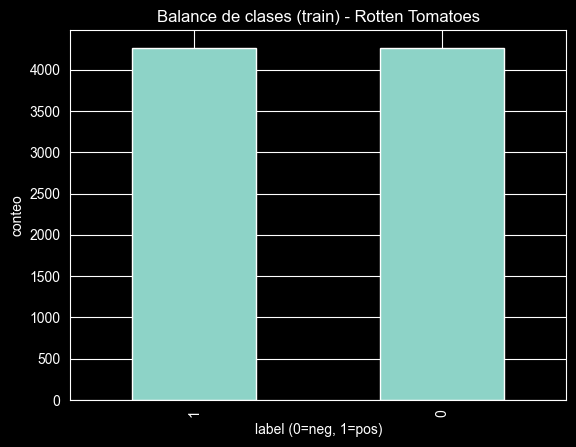

In [6]:
# %%
plt.figure()
train_df["label"].value_counts().plot(kind="bar")
plt.title("Balance de clases (train) - Rotten Tomatoes")
plt.xlabel("label (0=neg, 1=pos)")
plt.ylabel("conteo")
plt.show()

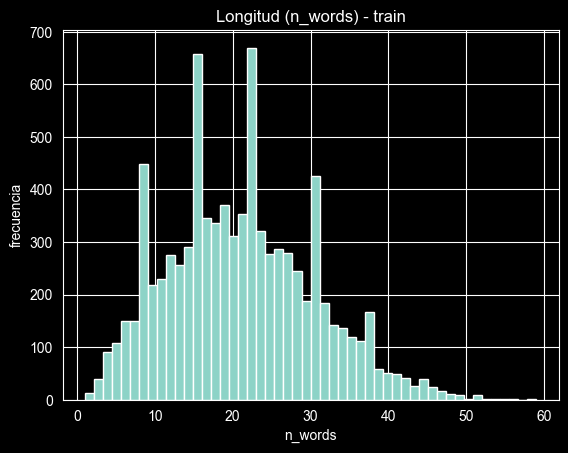

count    8530.000000
mean       20.992849
std         9.371094
min         1.000000
25%        14.000000
50%        20.000000
75%        27.000000
max        59.000000
Name: n_words, dtype: float64

In [7]:
# %%
train_df["n_words"] = train_df["text"].str.split().apply(len)
plt.figure()
plt.hist(train_df["n_words"], bins=50)
plt.title("Longitud (n_words) - train")
plt.xlabel("n_words")
plt.ylabel("frecuencia")
plt.show()

train_df["n_words"].describe()

In [8]:
# %%


EN_STOPWORDS = set(stopwords.words("english"))
NEGATIONS = {"no", "not", "nor", "n't"}
EN_STOPWORDS_SAFE = EN_STOPWORDS - NEGATIONS

def clean_text_basic(text: str) -> str:
    # quitar HTML
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    # minúsculas
    text = text.lower()
    # dejar letras, números, espacios y apóstrofe (para don't)
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    # colapsar espacios
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text: str):
    return clean_text_basic(text).split()

def remove_stopwords(tokens, stopset=EN_STOPWORDS_SAFE):
    return [t for t in tokens if t not in stopset]

def preprocess(text: str) -> str:
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    return " ".join(tokens)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sebas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
# %%
# Aplicar preprocesamiento al dataset
train_df["text_clean"] = train_df["text"].apply(preprocess)
val_df["text_clean"]   = val_df["text"].apply(preprocess)
test_df["text_clean"]  = test_df["text"].apply(preprocess)

train_df[["text","text_clean"]].head(3)

,text,text_clean
0,the rock is destined to be the 21st century's ...,rock destined 21st century's new conan going m...
1,"the gorgeously elaborate continuation of "" the...",gorgeously elaborate continuation lord rings t...
2,effective but too-tepid biopic,effective tepid biopic


In [10]:
# **Mini-análisis útil**
# - ¿Qué palabras quedan más frecuentes después de remover stopwords?
# Esto ayuda a entender si la limpieza está funcionando.

# %%


counter = Counter()
for t in train_df["text_clean"].head(3000):
    counter.update(t.split())

counter.most_common(20)

[('film', 437),
 ('movie', 288),
 ('not', 209),
 ('one', 192),
 ('like', 154),
 ('story', 124),
 ('good', 120),
 ('comedy', 120),
 ('well', 118),
 ('even', 115),
 ('way', 112),
 ('time', 107),
 ('best', 99),
 ('much', 88),
 ('make', 87),
 ('director', 87),
 ('funny', 87),
 ('life', 87),
 ('love', 85),
 ('characters', 85)]

### Punto 2 — Texto → Vectores (TF-IDF) + Modelo baseline (ML)

In [11]:
# %%


X_train = train_df["text_clean"].values
y_train = train_df["label"].values

X_val = val_df["text_clean"].values
y_val = val_df["label"].values

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    min_df=2,
    sublinear_tf=True
)

Xtr = tfidf.fit_transform(X_train)
Xva = tfidf.transform(X_val)

svm = LinearSVC()
svm.fit(Xtr, y_train)

pred_val = svm.predict(Xva)
print(classification_report(y_val, pred_val))

              precision    recall  f1-score   support

           0       0.75      0.77      0.76       533
           1       0.76      0.75      0.76       533

    accuracy                           0.76      1066
   macro avg       0.76      0.76      0.76      1066
weighted avg       0.76      0.76      0.76      1066



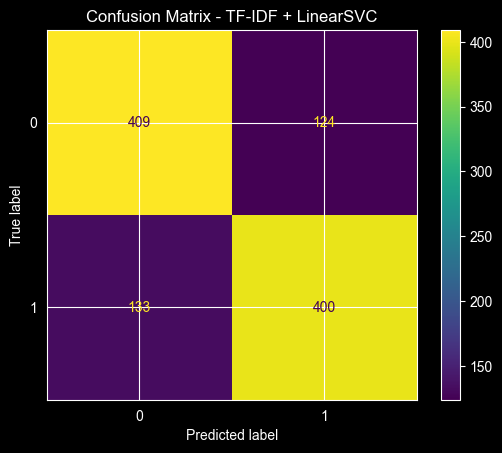

In [12]:
# %%
cm = confusion_matrix(y_val, pred_val)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix - TF-IDF + LinearSVC")
plt.show()

In [13]:
# **Pregunta guía**
# - ¿Por qué un modelo lineal funciona tan bien con TF-IDF?

### Punto 3 — Word2Vec (repaso): embeddings "estáticos"

In [14]:
# %%


# Tokenizar (ya limpio) para Word2Vec
sentences = [t.split() for t in train_df["text_clean"].values]

w2v = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=3,
    workers=2
)

w2v.wv.most_similar("good", topn=10)

[('not', 0.9998488426208496),
 ('would', 0.9998477101325989),
 ('one', 0.9998475313186646),
 ('much', 0.9998442530632019),
 ('plot', 0.9998422861099243),
 ('film', 0.9998397827148438),
 ('enough', 0.9998380541801453),
 ('us', 0.9998363852500916),
 ('movie', 0.9998311996459961),
 ('films', 0.9998270869255066)]

In [15]:
# %%
# Embedding de frase como promedio de vectores de palabras
def sentence_embedding_avg(text, model, dim=100):
    tokens = text.split()
    vecs = []
    for tok in tokens:
        if tok in model.wv:
            vecs.append(model.wv[tok])
    if not vecs:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)

Xtr_emb = np.vstack([sentence_embedding_avg(t, w2v, dim=100) for t in X_train])
Xva_emb = np.vstack([sentence_embedding_avg(t, w2v, dim=100) for t in X_val])

Xtr_emb.shape, Xva_emb.shape

((8530, 100), (1066, 100))

In [16]:
# %%
# Clasificador simple sobre embeddings promedio


clf = LogisticRegression(max_iter=2000)
clf.fit(Xtr_emb, y_train)

pred_emb = clf.predict(Xva_emb)
print("Word2Vec(avg) + LogisticRegression")
print(classification_report(y_val, pred_emb))

Word2Vec(avg) + LogisticRegression
              precision    recall  f1-score   support

           0       0.51      0.53      0.52       533
           1       0.51      0.48      0.49       533

    accuracy                           0.51      1066
   macro avg       0.51      0.51      0.51      1066
weighted avg       0.51      0.51      0.51      1066



In [17]:
# **Discusión corta**
# - TF-IDF suele superar a Word2Vec-promedio en sentimiento con textos cortos
# - Word2Vec es útil, pero NO es contextual: "bank" siempre igual
# - Aquí nace la motivación para BERT (contexto)

### Punto 4 — BERT: embeddings contextuales + evaluación (sentimiento)

In [3]:
# %%


device = 0 if torch.cuda.is_available() else -1

bert_sentiment = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device
)

bert_sentiment("This movie is not good at all. The plot is confusing.")

[{'label': 'NEGATIVE', 'score': 0.9997581839561462}]

In [1]:
# %%


# Dataset
ds = load_dataset("rotten_tomatoes")
val_df = ds["validation"].to_pandas()

# Modelo
device = 0 if torch.cuda.is_available() else -1
bert_sentiment = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device
)

# Evaluación
N = 400
texts_eval = val_df["text"].tolist()[:N]
y_true = val_df["label"].values[:N]

pred_labels = []
for t in texts_eval:
    out = bert_sentiment(t)[0]
    pred_labels.append(1 if out["label"] == "POSITIVE" else 0)

acc = accuracy_score(y_true, pred_labels)
print("Accuracy (DistilBERT SST-2) en subset val:", acc)

Accuracy (DistilBERT SST-2) en subset val: 0.9125


In [ ]:
# **Preguntas para responder**
# 1) ¿Cómo se compara este accuracy vs TF-IDF + SVM?
# 2) ¿Qué ventaja tiene un Transformer preentrenado?
# 3) ¿Por qué no fue necesario entrenarlo desde cero aquí?

###Punto 5 — Transformers: ideas clave + tareas NLP (más allá de sentimiento)

In [ ]:
## **Ideas clave**
# - Un Transformer usa "attention": cada palabra mira a las demás para entender contexto.
# - Por eso captura relaciones de largo alcance mejor que enfoques clásicos.
# - BERT (encoder) es muy bueno entendiendo; GPT (decoder) es muy bueno generando.

In [3]:
# %%


device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "Helsinki-NLP/opus-mt-en-es"
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name).to(device)

def translate(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        output = model.generate(**inputs)
    return tokenizer.decode(output[0], skip_special_tokens=True)

translate("This movie is not good. The story is confusing and the acting is weak.")

'Esta película no es buena, la historia es confusa y la actuación es débil.'

In [4]:
# %%


device = 0 if torch.cuda.is_available() else -1

summarizer = pipeline(
    "summarization",
    model="sshleifer/distilbart-cnn-12-6",
    device=device
)

long_text = """
The film begins with an interesting idea, but the execution is uneven.
Some scenes feel engaging, yet the pacing slows down in the middle.
The performances vary from strong to flat, and the dialogue can be repetitive.
In the end, the movie has a few memorable moments, but it does not fully deliver on its promise.
"""

summarizer(long_text, max_length=60, min_length=20, do_sample=False)

[{'summary_text': ' Some scenes feel engaging, yet the pacing slows down in the middle . The performances vary from strong to flat, and the dialogue can be repetitive .'}]

In [5]:
# ## Entregables
# 1) Resultados de TF-IDF + SVM (métricas)
# 2) Word2Vec: ejemplo de similitud + clasificación con embedding promedio
# 3) BERT: accuracy en un subset + comparación con TF-IDF
# 4) Responder 5 preguntas conceptuales:
#    - Diferencia TF-IDF vs Word2Vec vs BERT
#    - Qué significa "contextual"
#    - Por qué negaciones importan en stopwords
#    - Qué tareas adicionales soporta un Transformer
#    - Cuándo usarías un baseline clásico vs un Transformer